# Assignment 4: Training a DCGAN on Fashion-MNIST Dataset

**Name:** Prakruthi BR  
**Course:** BCA  
**Subject:** Generative AI

## Aim

To implement and train a Deep Convolutional Generative Adversarial Network (DCGAN) using the Fashion-MNIST dataset and observe how the generated images improve during training.

The model consists of two neural networks:

- **Generator** – Generates fake Fashion-MNIST images from random noise.
- **Discriminator** – Distinguishes between real and generated images.

The model is trained for **25 epochs**, and generated 4×4 image grids are saved after every 5 epochs for comparison.

## Introduction

A Generative Adversarial Network (GAN) is a deep learning model that consists of two competing neural networks called the Generator and the Discriminator.

The Generator takes a random noise vector as input and tries to generate realistic images. The Discriminator receives both real images from the dataset and fake images from the Generator and tries to identify whether they are real or fake.

In this assignment, a **Deep Convolutional GAN (DCGAN)** is implemented using the **Fashion-MNIST dataset**. Fashion-MNIST contains 28×28 grayscale images of different clothing items.

During training, the Generator gradually learns the patterns and shapes present in the dataset. The generated images are saved at epochs 5, 10, 15, 20, and 25 to observe the improvement in image quality.


## Step 1: Import Libraries – PyTorch and TensorFlow

In this step, the required Python libraries are imported.

**PyTorch** is used to build and train the Generator and Discriminator networks.

**TensorFlow** is also imported as required for the assignment.

Other libraries such as Torchvision are used for loading the Fashion-MNIST dataset, while Matplotlib is used for displaying images and plotting the training loss.

In [ ]:

# STEP 1: IMPORT LIBRARIES


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# TensorFlow
import tensorflow as tf

# Torchvision
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

# Visualization
import matplotlib.pyplot as plt

# Numerical operations
import numpy as np

# File and folder handling
import os

print("PyTorch Version:", torch.__version__)
print("TensorFlow Version:", tf.__version__)

PyTorch Version: 2.11.0+cu128
TensorFlow Version: 2.20.0


## Step 2: Set Basic Parameters

The basic parameters required for training the DCGAN are defined in this step.

The Fashion-MNIST images have a size of **28×28 pixels** and contain only one channel because they are grayscale images.

The model is trained for **25 epochs**. A batch size of 128 is used, and the Generator receives a noise vector of size 100.

The learning rate controls how quickly the neural networks update their weights during training.

In [ ]:

# STEP 2: SET BASIC PARAMETERS


# Image parameters
image_size = 28
channels = 1

# Training parameters
batch_size = 128
num_epochs = 25

# Generator input size
latent_dim = 100

# Learning parameters
learning_rate = 0.0002
beta1 = 0.5

# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("Image Size:", image_size)
print("Number of Channels:", channels)
print("Batch Size:", batch_size)
print("Latent Dimension:", latent_dim)
print("Number of Epochs:", num_epochs)
print("Learning Rate:", learning_rate)

Device: cuda
Image Size: 28
Number of Channels: 1
Batch Size: 128
Latent Dimension: 100
Number of Epochs: 25
Learning Rate: 0.0002


## Step 3: Create the Noise Vector

The Generator does not receive a real image as input. Instead, it starts with a vector containing random values called a **noise vector** or **latent vector**.

In this assignment, the noise vector has a dimension of 100.

The Generator learns to transform this random input into a meaningful Fashion-MNIST-like image.

The same fixed noise vector is later used to compare the generated images at different epochs. This makes it easier to observe the effect of training.

In [ ]:

# STEP 3: CREATE NOISE VECTOR


noise = torch.randn(16, latent_dim, 1, 1, device=device)

print("Noise shape:", noise.shape)

noise_vector = torch.randn(
    16,
    latent_dim,
    1,
    1
).to(device)

print("Noise Vector Shape:", noise_vector.shape)

Noise shape: torch.Size([16, 100, 1, 1])
Noise Vector Shape: torch.Size([16, 100, 1, 1])


## Step 4: Load the Fashion-MNIST Dataset

Fashion-MNIST is used as the training dataset.

It contains grayscale images of different fashion items such as shirts, trousers, shoes, bags, and other clothing categories.

Each image has a size of **28×28 pixels**.

The dataset is loaded using Torchvision and divided into batches using a DataLoader.

The images are shuffled during training so that the model does not always see the images in the same order.

In [ ]:


# Step 4: Load Fashion-MNIST dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Number of training images:", len(dataset))
print("Number of batches:", len(dataloader))

Number of training images: 60000
Number of batches: 469


## Step 5: Normalize Images from -1 to +1

The Fashion-MNIST images are normalized to the range **-1 to +1**.

This is done because the final activation function of the Generator is **Tanh**, which also produces values between -1 and +1.

Using the same range for the real images and generated images helps the Generator produce outputs that are compatible with the training data.

Therefore:

**Original pixel range → normalized to -1 to +1**

**Generator output → Tanh → -1 to +1**

In [ ]:

# STEP 5: NORMALIZE IMAGES TO -1 AND +1


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,),
        (0.5,)
    )
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Fashion-MNIST images are normalized to -1 and +1.")

Fashion-MNIST images are normalized to -1 and +1.


## Step 6: Tanh as the Final Activation of the Generator

The Generator uses the **Tanh activation function** as its final layer.

Tanh produces values between **-1 and +1**.

Since the Fashion-MNIST images are also normalized to the same range, Tanh is suitable for producing the final generated image.

The final output of the Generator is a **28×28 grayscale image**.

In [18]:
# Step 6: Tanh as the Final Activation of the Generator
nn.Tanh()

Tanh()

## Step 7: Generate and Obtain Original Images

Before training the DCGAN, a batch of real images is obtained from the Fashion-MNIST dataset.

These images represent the original data that the Generator is trying to learn from.

The original images will later be compared with the generated images to understand how well the Generator learns the visual patterns of the dataset.

In [ ]:

# STEP 7: GET ORIGINAL IMAGES




real_images, real_labels_dataset = next(iter(dataloader))
real_images = real_images.to(device)

print("Original image batch shape:", real_images.shape)

Original image batch shape: torch.Size([128, 1, 28, 28])


## Step 8: Display Original Fashion-MNIST Images

In this step, a 4×4 grid of original Fashion-MNIST images is displayed.

These are real images from the dataset and are used as a reference for comparing the images generated by the Generator.

The images are displayed in grayscale because Fashion-MNIST contains grayscale images.

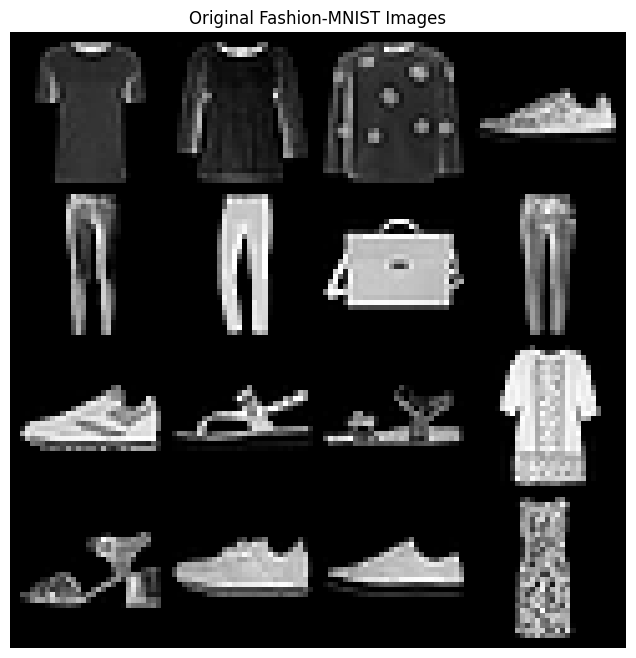

In [ ]:

# STEP 8: DISPLAY ORIGINAL IMAGES



import torchvision.utils as vutils
plt.figure(figsize=(8, 8))

plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_images[:16],
            nrow=4,
            padding=2,
            normalize=True
        ).cpu(),
        (1, 2, 0)
    )
)

plt.title("Original Fashion-MNIST Images")
plt.axis("off")
plt.show()

## Step 9: Build the Generator

The Generator is the network responsible for creating new images.

It starts with a random noise vector and progressively transforms it into a 28×28 image.

The Generator uses **transposed convolutional layers** to increase the spatial dimensions of the feature maps.

The basic transformation is:

100 × 1 × 1  
↓  
128 × 7 × 7  
↓  
64 × 14 × 14  
↓  
1 × 28 × 28

The final Tanh activation produces the generated image in the range -1 to +1.

In [ ]:

# STEP 9: BUILD THE GENERATOR


class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            
            # Layer 1
            # 100 x 1 x 1 -> 128 x 7 x 7
            

            nn.ConvTranspose2d(
                latent_dim,
                128,
                kernel_size=7,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(True),


            
            # Layer 2
            # 7 x 7 -> 14 x 14
            

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),


            
            # Layer 3
            # 14 x 14 -> 28 x 28
            

            nn.ConvTranspose2d(
                64,
                channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),


            
            # Final activation
            

            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# Create Generator
generator = Generator().to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)


## Step 10: Transposed Convolution in the Generator

The Generator starts with random numbers called a latent or noise vector.

These random values are passed through transposed convolutional layers.

A transposed convolution helps increase the spatial dimensions of the feature maps.

In this model, the image size increases as follows:

**1×1 → 7×7 → 14×14 → 28×28**

As the Generator progresses through these layers, it learns different features such as edges, shapes, and clothing structures.

Therefore, the Generator transforms random noise into a complete Fashion-MNIST-like image.

## Step 11: Test the Generator Before Training

Before training, the Generator is tested using random noise.

At this stage, the Generator has not learned any useful patterns from the Fashion-MNIST dataset.

Therefore, the generated images are expected to look like random noise or unclear patterns.

This step provides a baseline for comparing the generated images before and after training.

In [ ]:

# STEP 11: TEST GENERATOR BEFORE TRAINING


test_noise = torch.randn(
    16,
    latent_dim,
    1,
    1
).to(device)

with torch.no_grad():

    generated_before_training = generator(
        test_noise
    )

print(
    "Generated Images Shape:",
    generated_before_training.shape
)

Generated Images Shape: torch.Size([16, 1, 28, 28])


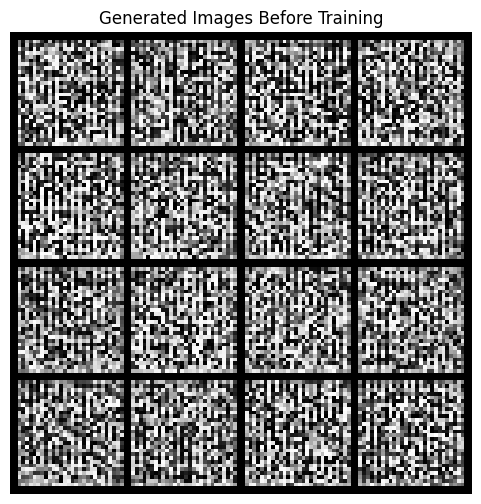

In [ ]:


with torch.no_grad():
    fake_images = generator(noise)

grid = vutils.make_grid(fake_images, nrow=4, normalize=True, padding=2)

# Move tensor from GPU to CPU before displaying
grid = grid.cpu()

plt.figure(figsize=(6, 6))
plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray"
)
plt.axis("off")
plt.title("Generated Images Before Training")
plt.show()

## Step 12: Build the Discriminator

The Discriminator is the second neural network in the GAN.

Its main purpose is to distinguish between real and fake images.

It receives:

- Real Fashion-MNIST images from the dataset.
- Fake images generated by the Generator.

The Discriminator uses convolutional layers to extract important features from the images.

Its final output represents the probability that the input image is real.

In [ ]:

# STEP 12: BUILD THE DISCRIMINATOR


class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            
            # Layer 1
            # 28 x 28 -> 14 x 14
            

            nn.Conv2d(
                channels,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            
            # Layer 2
            # 14 x 14 -> 7 x 7
            

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            # Flatten
            nn.Flatten(),


            # Classification
            nn.Linear(
                128 * 7 * 7,
                1
            ),


            # Final probability
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# Create Discriminator
discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


## Step 13: Use Sigmoid Activation

The final layer of the Discriminator uses the **Sigmoid activation function**.

Sigmoid produces an output between **0 and 1**.

This output represents the probability that an image is real.

For example:

- Value close to 1 → likely real
- Value close to 0 → likely fake

Therefore, Sigmoid is suitable for the binary classification task of distinguishing real images from generated images.

In [25]:
nn.Sigmoid()

Sigmoid()

## Step 14: Define Binary Cross Entropy Loss and Optimizers

The **Binary Cross Entropy (BCE)** loss function is used because the Discriminator performs binary classification.

The two classes are:

- **1 → Real**
- **0 → Fake**

The Adam optimizer is used to update the weights of both the Generator and Discriminator.

Two separate optimizers are used because the Generator and Discriminator are trained independently.

In [ ]:

# STEP 14: LOSS FUNCTION AND OPTIMIZERS


# Binary Cross Entropy loss
criterion = nn.BCELoss()

# Generator optimizer
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(beta1, 0.999)
)

# Discriminator optimizer
optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(beta1, 0.999)
)

print("Loss Function: Binary Cross Entropy")
print("Optimizer: Adam")

Loss Function: Binary Cross Entropy
Optimizer: Adam


## Step 15: Transformation of Neurons/Features by the Generator

The Generator does not directly convert one image into another.

Instead, it transforms the random noise vector into learned feature representations.

The transposed convolutional layers progressively increase the feature-map size.

The Generator learns to represent:

Random patterns  
↓  
Edges  
↓  
Basic shapes  
↓  
Clothing structures  
↓  
Fashion-MNIST-like images

Therefore, the Generator gradually learns how to create realistic images from random noise.

## Step 16: Train the Discriminator

During each training iteration, the Discriminator is trained using both real and generated images.

For real images, the target label is **1**.

For generated images, the target label is **0**.

The Discriminator calculates its loss for both types of images and combines them into the total Discriminator loss.

The weights of the Discriminator are then updated using backpropagation and the Adam optimizer.

The goal of the Discriminator is to correctly identify real and fake images.

In [ ]:
# Step 16: Test one Discriminator training step

# Get a batch of real images
real_images, _ = next(iter(dataloader))
real_images = real_images.to(device)

# Create labels
real_labels = torch.ones(real_images.size(0), 1, device=device)
fake_labels = torch.zeros(real_images.size(0), 1, device=device)

# Train Discriminator


optimizer_D.zero_grad()

# Real images
real_output = discriminator(real_images)

loss_D_real = criterion(
    real_output,
    real_labels
)

# Generate fake images
noise = torch.randn(
    real_images.size(0),
    latent_dim,
    1,
    1,
    device=device
)

fake_images = generator(noise)

# Fake images
fake_output = discriminator(fake_images.detach())

loss_D_fake = criterion(
    fake_output,
    fake_labels
)

# Total Discriminator loss
loss_D = loss_D_real + loss_D_fake

# Backpropagation
loss_D.backward()

# Update Discriminator
optimizer_D.step()

print("Real Loss:", loss_D_real.item())
print("Fake Loss:", loss_D_fake.item())
print("Total Discriminator Loss:", loss_D.item())

Real Loss: 0.8256751298904419
Fake Loss: 0.5466766357421875
Total Discriminator Loss: 1.3723517656326294


## Step 17: Train the Generator

After training the Discriminator, the Generator is trained.

The Generator creates fake images from random noise and sends them to the Discriminator.

The Generator's goal is to make the Discriminator classify these generated images as **real**.

Therefore, the Generator tries to produce increasingly realistic images.

The Generator loss is calculated using Binary Cross Entropy, and its weights are updated using the Adam optimizer.

In [28]:
# Step 17: Test one Generator training step

optimizer_G.zero_grad()

# Generate new fake images
noise = torch.randn(
    real_images.size(0),
    latent_dim,
    1,
    1,
    device=device
)

fake_images = generator(noise)

# Discriminator evaluates fake images
output = discriminator(fake_images)

# Generator wants fake images to be classified as real
loss_G = criterion(
    output,
    real_labels
)

# Backpropagation
loss_G.backward()

# Update Generator
optimizer_G.step()

print("Generator Loss:", loss_G.item())

Generator Loss: 0.9091479778289795


## Step 18: Display the Training Loss

During training, the Generator loss and Discriminator loss are calculated and displayed for every epoch.

The losses help us monitor the behavior of both networks during training.

GAN losses may fluctuate because the Generator and Discriminator are competing against each other.

Therefore, the losses do not necessarily decrease continuously like they often do in a normal classification model.

## Step 19: Train the Model for 25 Epochs

The DCGAN is trained for a total of **25 epochs**.

During every epoch:

1. Real images are given to the Discriminator.
2. The Generator creates fake images from random noise.
3. The Discriminator learns to distinguish real and fake images.
4. The Generator learns to fool the Discriminator.
5. Generator and Discriminator losses are recorded.

The model is evaluated visually after every 5 epochs.

In [ ]:
# Step 19: Complete DCGAN training for 25 epochs

# Create folder for generated images
os.makedirs("generated_images", exist_ok=True)

# Loss lists
G_losses = []
D_losses = []

# Epoch average losses
epoch_G_losses = []
epoch_D_losses = []

# Fixed noise for fair comparison
fixed_noise = torch.randn(
    16,
    latent_dim,
    1,
    1,
    device=device
)

print("Starting DCGAN training...\n")

for epoch in range(num_epochs):

    generator.train()
    discriminator.train()

    running_G_loss = 0.0
    running_D_loss = 0.0

    for batch_idx, (real_images, _) in enumerate(dataloader):

        # Move real images to device
        real_images = real_images.to(device)

        current_batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(
            current_batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            current_batch_size,
            1,
            device=device
        )

      
        # 1. Train Discriminator
        

        optimizer_D.zero_grad()

        # Discriminator on real images
        real_output = discriminator(real_images)

        loss_D_real = criterion(
            real_output,
            real_labels
        )

        # Generate fake images
        noise = torch.randn(
            current_batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        # Discriminator on fake images
        fake_output = discriminator(
            fake_images.detach()
        )

        loss_D_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total Discriminator loss
        loss_D = loss_D_real + loss_D_fake

        # Backpropagation
        loss_D.backward()

        # Update Discriminator
        optimizer_D.step()

        
        # 2. Train Generator
       

        optimizer_G.zero_grad()

        # Generate another batch of fake images
        noise = torch.randn(
            current_batch_size,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = generator(noise)

        # Discriminator evaluates fake images
        output = discriminator(fake_images)

        # Generator wants discriminator to predict real
        loss_G = criterion(
            output,
            real_labels
        )

        # Backpropagation
        loss_G.backward()

        # Update Generator
        optimizer_G.step()

        
        # 3. Record losses
        

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        running_G_loss += loss_G.item()
        running_D_loss += loss_D.item()

    # Average loss for the epoch
    avg_G_loss = running_G_loss / len(dataloader)
    avg_D_loss = running_D_loss / len(dataloader)

    epoch_G_losses.append(avg_G_loss)
    epoch_D_losses.append(avg_D_loss)

   
    # 4. Print losses
  

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Generator Loss: {avg_G_loss:.4f} | "
        f"Discriminator Loss: {avg_D_loss:.4f}"
    )

  
    # 5. Save images every 5 epochs
   

    if (epoch + 1) % 5 == 0:

        generator.eval()

        with torch.no_grad():
            generated_images = generator(fixed_noise)

        filename = f"generated_images/epoch_{epoch + 1}.png"

        vutils.save_image(
            generated_images,
            filename,
            nrow=4,
            normalize=True,
            padding=2
        )

        generator.train()

        print(f"Saved generated images: {filename}")

print("\nTraining completed successfully!")

Starting DCGAN training...

Epoch [1/25] Generator Loss: 1.5508 | Discriminator Loss: 0.7156
Epoch [2/25] Generator Loss: 1.3733 | Discriminator Loss: 0.8190
Epoch [3/25] Generator Loss: 1.1829 | Discriminator Loss: 0.9829
Epoch [4/25] Generator Loss: 1.1052 | Discriminator Loss: 1.0537
Epoch [5/25] Generator Loss: 1.0966 | Discriminator Loss: 1.0707
Saved generated images: generated_images/epoch_5.png
Epoch [6/25] Generator Loss: 1.0985 | Discriminator Loss: 1.0705
Epoch [7/25] Generator Loss: 1.1006 | Discriminator Loss: 1.0674
Epoch [8/25] Generator Loss: 1.1105 | Discriminator Loss: 1.0615
Epoch [9/25] Generator Loss: 1.1173 | Discriminator Loss: 1.0601
Epoch [10/25] Generator Loss: 1.1194 | Discriminator Loss: 1.0548
Saved generated images: generated_images/epoch_10.png
Epoch [11/25] Generator Loss: 1.1320 | Discriminator Loss: 1.0482
Epoch [12/25] Generator Loss: 1.1484 | Discriminator Loss: 1.0455
Epoch [13/25] Generator Loss: 1.1482 | Discriminator Loss: 1.0405
Epoch [14/25] Ge

## Step 20: Save 4×4 Generated Images Every 5 Epochs

To observe the progress of the Generator, a 4×4 grid containing 16 generated images is saved after every 5 epochs.

Images are saved at:

- Epoch 5
- Epoch 10
- Epoch 15
- Epoch 20
- Epoch 25

The same fixed noise vector is used at each checkpoint so that the generated results can be compared fairly.

This allows us to visually observe how the image quality changes throughout training.

In [30]:
# Step 20: Check saved image files

saved_files = [
    "generated_images/epoch_5.png",
    "generated_images/epoch_10.png",
    "generated_images/epoch_15.png",
    "generated_images/epoch_20.png",
    "generated_images/epoch_25.png"
]

for file in saved_files:
    print(file, "->", os.path.exists(file))

generated_images/epoch_5.png -> True
generated_images/epoch_10.png -> True
generated_images/epoch_15.png -> True
generated_images/epoch_20.png -> True
generated_images/epoch_25.png -> True


## Step 21: Output Generator and Discriminator Loss

The average Generator and Discriminator losses are displayed after each epoch.

The output contains:

- Epoch number
- Discriminator loss
- Generator loss

The actual loss values obtained during execution are recorded for further analysis.

Loss values may fluctuate because GAN training involves competition between the two networks.

In [31]:
# Step 21: Display epoch losses

print("Epoch-wise Losses\n")

for epoch in range(num_epochs):
    print(
        f"Epoch {epoch + 1:02d} | "
        f"Generator Loss = {epoch_G_losses[epoch]:.4f} | "
        f"Discriminator Loss = {epoch_D_losses[epoch]:.4f}"
    )

Epoch-wise Losses

Epoch 01 | Generator Loss = 1.5508 | Discriminator Loss = 0.7156
Epoch 02 | Generator Loss = 1.3733 | Discriminator Loss = 0.8190
Epoch 03 | Generator Loss = 1.1829 | Discriminator Loss = 0.9829
Epoch 04 | Generator Loss = 1.1052 | Discriminator Loss = 1.0537
Epoch 05 | Generator Loss = 1.0966 | Discriminator Loss = 1.0707
Epoch 06 | Generator Loss = 1.0985 | Discriminator Loss = 1.0705
Epoch 07 | Generator Loss = 1.1006 | Discriminator Loss = 1.0674
Epoch 08 | Generator Loss = 1.1105 | Discriminator Loss = 1.0615
Epoch 09 | Generator Loss = 1.1173 | Discriminator Loss = 1.0601
Epoch 10 | Generator Loss = 1.1194 | Discriminator Loss = 1.0548
Epoch 11 | Generator Loss = 1.1320 | Discriminator Loss = 1.0482
Epoch 12 | Generator Loss = 1.1484 | Discriminator Loss = 1.0455
Epoch 13 | Generator Loss = 1.1482 | Discriminator Loss = 1.0405
Epoch 14 | Generator Loss = 1.1716 | Discriminator Loss = 1.0342
Epoch 15 | Generator Loss = 1.1723 | Discriminator Loss = 1.0267
Epoch 

## Step 22: Display Generated Images at Different Epochs

The generated images saved at Epochs 5, 10, 15, 20, and 25 are displayed for visual comparison.

This helps us observe how the Generator develops from producing unclear patterns to producing more structured Fashion-MNIST-like images.

The comparison focuses on:

- Image clarity
- Shape formation
- Clothing-like structures
- Noise
- Overall similarity to the original dataset

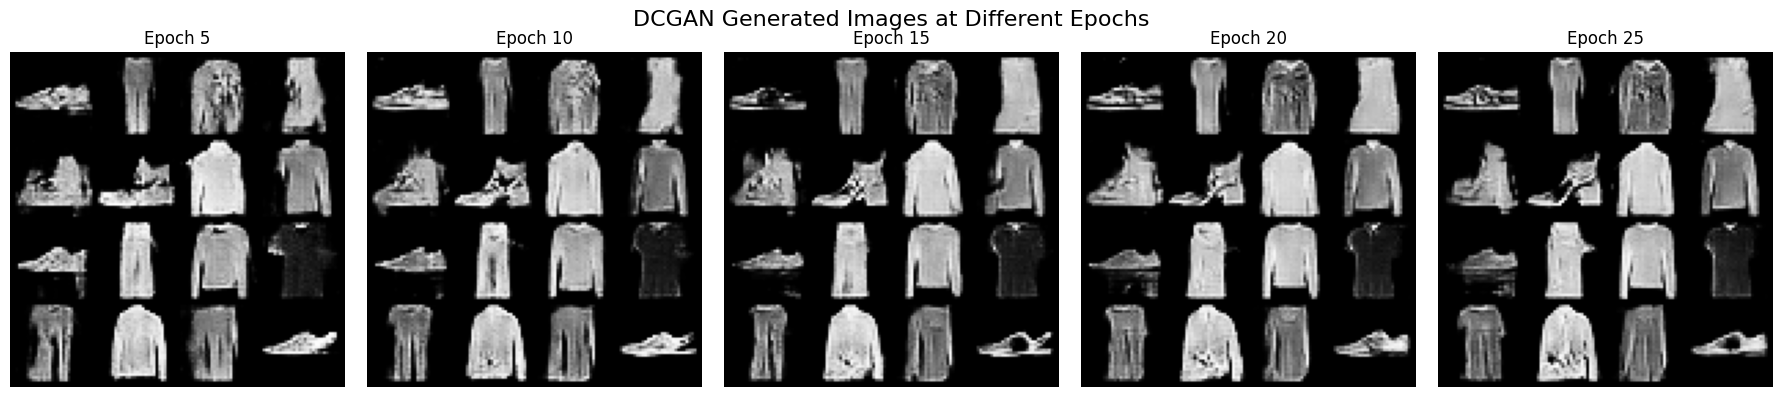

In [38]:
# Step 22: Display generated images from different epochs

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

epochs_to_show = [5, 10, 15, 20, 25]

for ax, epoch in zip(axes, epochs_to_show):

    image_path = f"generated_images/epoch_{epoch}.png"

    image = plt.imread(image_path)

    ax.imshow(image)
    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.suptitle(
    "DCGAN Generated Images at Different Epochs",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 23: Record Generator and Discriminator Losses

The Generator and Discriminator losses are stored during training.

Recording the losses allows us to:

- Monitor training behavior.
- Compare Generator and Discriminator performance.
- Plot the loss curves.
- Identify possible fluctuations or instability.

The recorded losses are used in the next step to create the training loss graph.

In [39]:
# Step 23: Store and display losses

print("Generator losses recorded:", len(G_losses))
print("Discriminator losses recorded:", len(D_losses))

print("\nFirst 5 Generator losses:")
print(G_losses[:5])

print("\nFirst 5 Discriminator losses:")
print(D_losses[:5])

Generator losses recorded: 11725
Discriminator losses recorded: 11725

First 5 Generator losses:
[0.8663641810417175, 0.8772758841514587, 1.0648599863052368, 1.0988736152648926, 1.1610233783721924]

First 5 Discriminator losses:
[1.1259801387786865, 1.0543220043182373, 0.9486645460128784, 0.8713760375976562, 0.7798106074333191]


## Step 24: Plot Generator and Discriminator Loss Graph

A graph is plotted using the recorded Generator and Discriminator losses.

The **X-axis** represents the number of epochs.

The **Y-axis** represents the loss.

Two curves are shown:

- Generator Loss
- Discriminator Loss

The graph helps us understand how the two networks behave during the 25 epochs of training.

Because GANs involve two competing networks, fluctuations in the loss curves are normal.

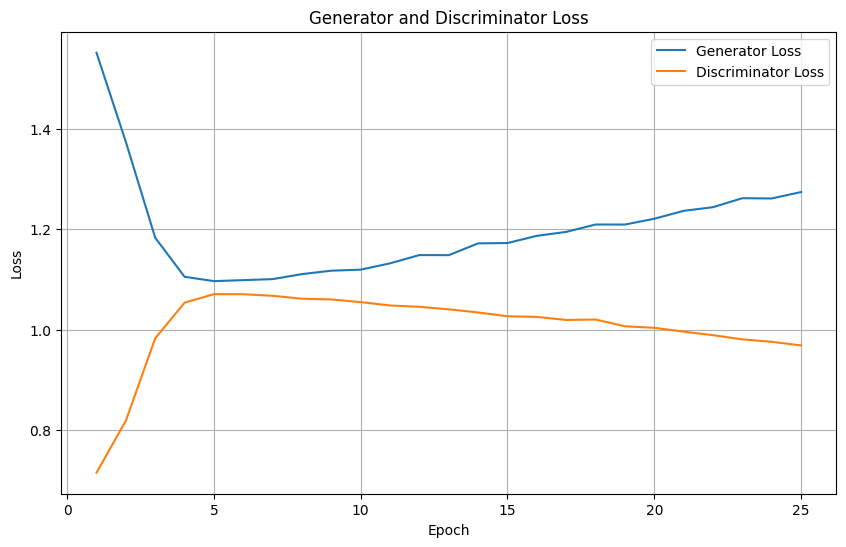

In [40]:
# Step 24: Plot loss graph

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    epoch_G_losses,
    label="Generator Loss"
)

plt.plot(
    epochs_range,
    epoch_D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss")
plt.legend()
plt.grid(True)

plt.show()

## Step 25: Compare Generated Images from Epochs 5, 10, 15, 20 and 25

The generated images from Epochs 5, 10, 15, 20, and 25 are compared visually.

At the beginning of training, the images are expected to contain more noise and less recognizable structure.

As training progresses, the Generator learns more useful features from Fashion-MNIST.

The comparison helps determine the stage at which clothing-like shapes become recognizable and whether the image quality improves throughout training.

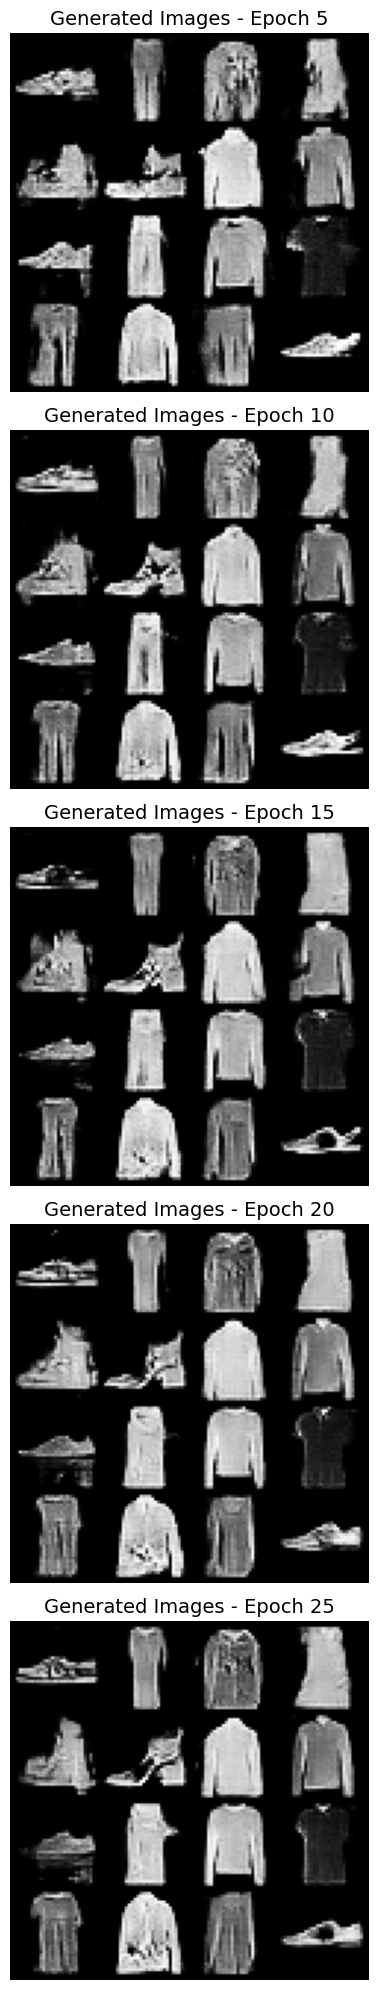

In [41]:
# Step 25: Detailed comparison

fig, axes = plt.subplots(5, 1, figsize=(8, 20))

epochs_to_compare = [5, 10, 15, 20, 25]

for ax, epoch in zip(axes, epochs_to_compare):

    image_path = f"generated_images/epoch_{epoch}.png"
    image = plt.imread(image_path)

    ax.imshow(image)
    ax.set_title(
        f"Generated Images - Epoch {epoch}",
        fontsize=14
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Analysis Question 1

### How do the images change from Epoch 5 to Epoch 25?

At Epoch 5, the generated images are generally unclear and contain random or noisy patterns because the Generator has only started learning from the dataset.

As the number of epochs increases, the Generator learns more meaningful features such as edges, shapes, and clothing structures.

By Epoch 25, the generated images are generally more structured and recognizable compared with the images generated at Epoch 5.

## Analysis Question 2

### Can you observe at which epoch clothing-like shapes become recognizable?

Clothing-like shapes begin to appear as the Generator learns more features from the Fashion-MNIST dataset.

In the generated results, the epoch at which the shapes first become recognizable can be identified by comparing Epochs 5, 10, 15, 20, and 25.

Based on the observed images, the recognizable structures should be reported using the actual output obtained during training.

## Analysis Question 3

### Does the image continue improving throughout training?

The overall quality of the generated images generally improves as training progresses.

However, the improvement is not necessarily continuous at every epoch. Some generated images may temporarily contain noise or distorted shapes.

This happens because GAN training can be unstable due to the competition between the Generator and Discriminator.

Therefore, the overall trend can improve even though individual epochs may show fluctuations.

## Analysis Question 4

### Can instability be observed during training?

Yes, some instability can be observed during GAN training.

The Generator and Discriminator are continuously competing with each other. When the Discriminator becomes better at identifying fake images, the Generator tries to improve its generated images.

Because of this competition, the Generator and Discriminator losses may increase and decrease instead of following a smooth downward trend.

Some variation in the generated image quality can also occur during training.